### Simple Linear Regression: Price vs. Month

This section demonstrates a straightforward linear regression model using 'Month' as the independent variable to predict 'Prices'. The plot will show the actual prices and the fitted regression line.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import datetime

# Ensure df is available and has the correct columns
# Based on the kernel state, 'df' is already prepared with 'Days' and 'Prices' and a DatetimeIndex.
# So we can proceed directly.

df = pd.read_csv('Nat_Gas.csv', parse_dates=['Dates'], index_col='Dates')
# Create a 'Days' column from the DateTimeIndex
df["Days"] = (df.index - df.index.min()).days

# Define feature (X) and target (y) for simple linear regression
X_simple = df[['Days']] # Corrected to use 'Days' as the feature
y_simple = df['Prices']

# Initialize and train a simple Linear Regression model
simple_lr_model = LinearRegression()
simple_lr_model.fit(X_simple, y_simple)

# Make predictions for the entire dataset
simple_lr_predictions = simple_lr_model.predict(X_simple)

print("Simple Linear Regression Model Coefficients:")
print(f"Intercept: {simple_lr_model.intercept_:.2f}")
print(f"Coefficient (Days): {simple_lr_model.coef_[0]:.2f}")

Simple Linear Regression Model Coefficients:
Intercept: 10.29
Coefficient (Days): 0.00


/tmp/ipykernel_7514/159498062.py:11: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv('Nat_Gas.csv', parse_dates=['Dates'], index_col='Dates')


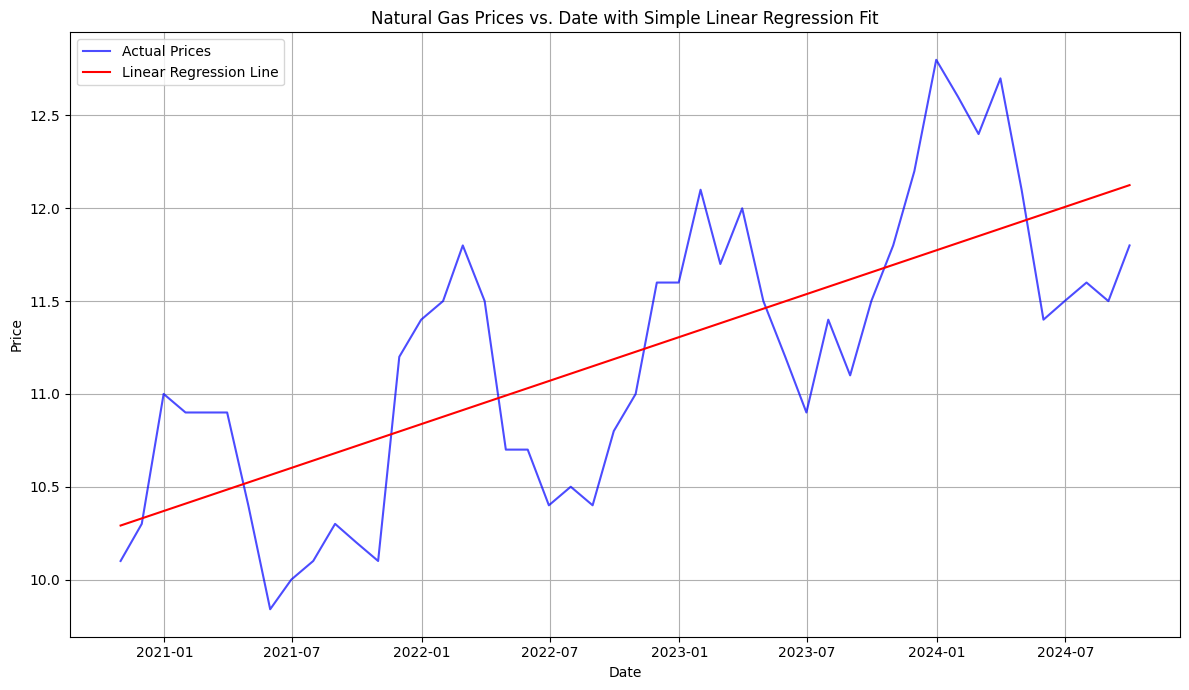

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 7))

# Plot actual prices against their dates
plt.plot(df.index, df['Prices'], label='Actual Prices', color='blue', alpha=0.7)

# Plot the simple linear regression line against dates
# The simple_lr_predictions align with the index of df
plt.plot(df.index, simple_lr_predictions, label='Linear Regression Line', color='red', linestyle='-')

plt.xlabel('Date')
plt.ylabel('Price')
plt.title('Natural Gas Prices vs. Date with Simple Linear Regression Fit')
plt.legend()
plt.grid(True)
# plt.xticks(np.arange(1, 13, 1)) # Removed as x-axis is now dates, not months
plt.tight_layout()
plt.show()

In [4]:
import datetime

# Get the maximum date from the DataFrame
max_date = df.index.max()

# Calculate the date one year after the maximum date
# Using pd.DateOffset for consistent date arithmetic, especially with leap years
date_one_year_after_max = max_date + pd.DateOffset(years=1)

# Get the minimum date from the DataFrame (the reference point for 'Days')
min_date = df.index.min()

# Calculate the 'Days' value for this new date
days_one_year_after_max = (date_one_year_after_max - min_date).days

print(f"Max Date in dataset: {max_date.strftime('%Y-%m-%d')}")
print(f"Date one year after max: {date_one_year_after_max.strftime('%Y-%m-%d')}")
print(f"Days value for one year after max date: {days_one_year_after_max}")

Max Date in dataset: 2024-09-30
Date one year after max: 2025-09-30
Days value for one year after max date: 1795


In [7]:
# Determine the last date in your existing DataFrame
last_date = df.index.max()

# Generate a range of future dates for the next 12 months (e.g., monthly)
# We'll use 'MS' for Month Start frequency to align with the data's monthly nature
future_dates = pd.date_range(start=last_date + pd.DateOffset(days=1),
                             periods=12,
                             freq='MS')

# Create a DataFrame for future predictions
future_df = pd.DataFrame(index=future_dates)

# Calculate 'Days' for these future dates, relative to the original start date
future_df['Days'] = (future_df.index - df.index.min()).days

# Use the trained model to predict prices for these future 'Days'
future_predictions = simple_lr_model.predict(future_df[['Days']])

# Add predictions to the future_df
future_df['Predicted Prices'] = future_predictions

display(future_df.head(12))


,Days,Predicted Prices
2024-10-01,1431,12.126118
2024-11-01,1462,12.165871
2024-12-01,1492,12.204343
2025-01-01,1523,12.244096
2025-02-01,1554,12.283850
2025-03-01,1582,12.319756
2025-04-01,1613,12.359510
2025-05-01,1643,12.397981
2025-06-01,1674,12.437735
2025-07-01,1704,12.476206


In [8]:
# Predict the price for the specific date one year after max
predicted_price_one_year_after_max = simple_lr_model.predict([[days_one_year_after_max]])[0]

# Create a Series for the new prediction, using the specific future date as its index
new_future_point_data = {
    'Days': days_one_year_after_max,
    'Predicted Prices': predicted_price_one_year_after_max
}

# Create a single-row DataFrame from this data
new_future_row_df = pd.DataFrame([new_future_point_data], index=[date_one_year_after_max])

# Concatenate the new prediction to future_df
# Ensure future_df is defined (it should be from previous cells)
future_df = pd.concat([future_df, new_future_row_df])

print("Updated Future Predictions DataFrame (last 5 rows including the new point):")
display(future_df.tail(5))

Updated Future Predictions DataFrame (last 5 rows including the new point):


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


,Days,Predicted Prices
2025-06-01,1674,12.437735
2025-07-01,1704,12.476206
2025-08-01,1735,12.515959
2025-09-01,1766,12.555713
2025-09-30,1795,12.592902


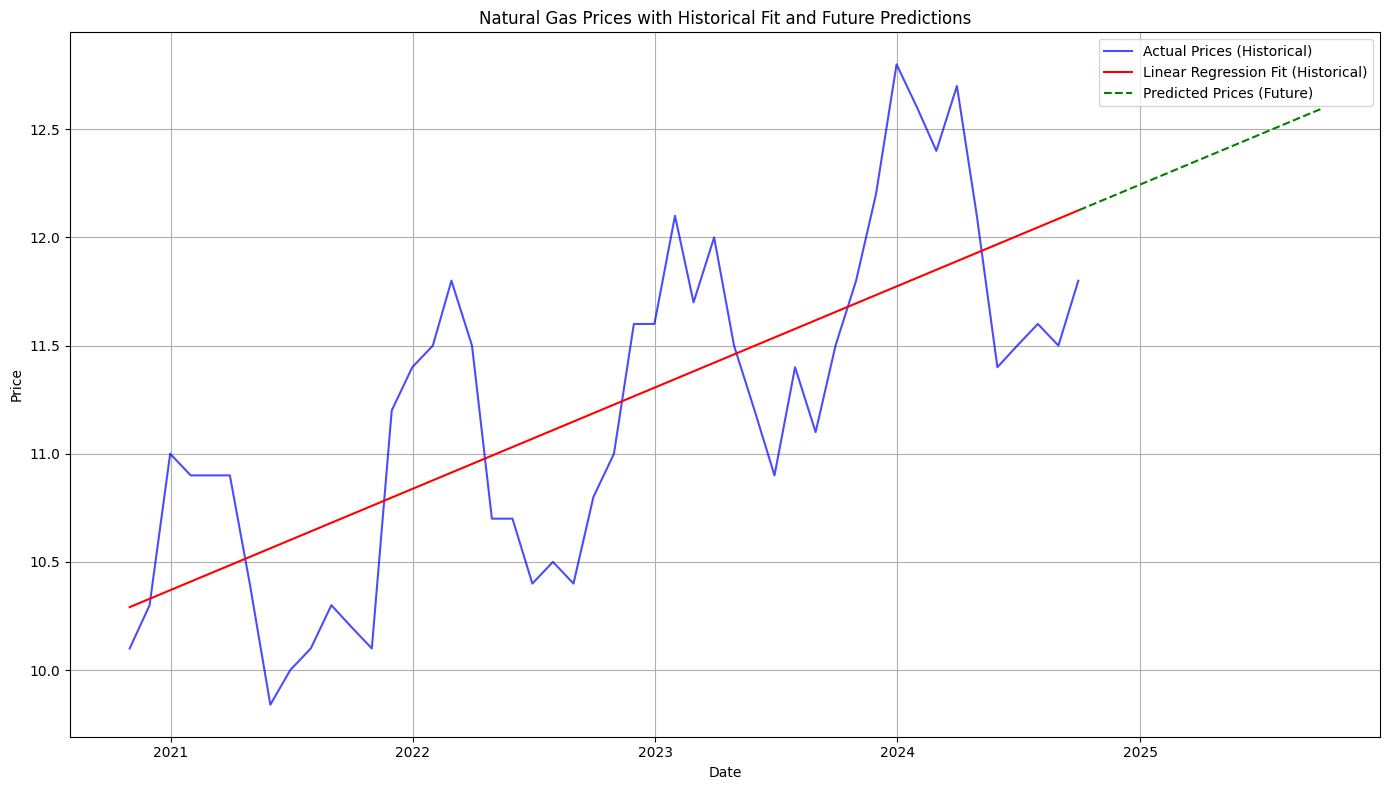

In [9]:
plt.figure(figsize=(14, 8))

# Plot actual prices against their dates
plt.plot(df.index, df['Prices'], label='Actual Prices (Historical)', color='blue', alpha=0.7)

# Plot the simple linear regression line for historical data
plt.plot(df.index, simple_lr_predictions, label='Linear Regression Fit (Historical)', color='red', linestyle='-')

# Plot the predicted prices for the future
plt.plot(future_df.index, future_df['Predicted Prices'], label='Predicted Prices (Future)', color='green', linestyle='--')

plt.xlabel('Date')
plt.ylabel('Price')
plt.title('Natural Gas Prices with Historical Fit and Future Predictions')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

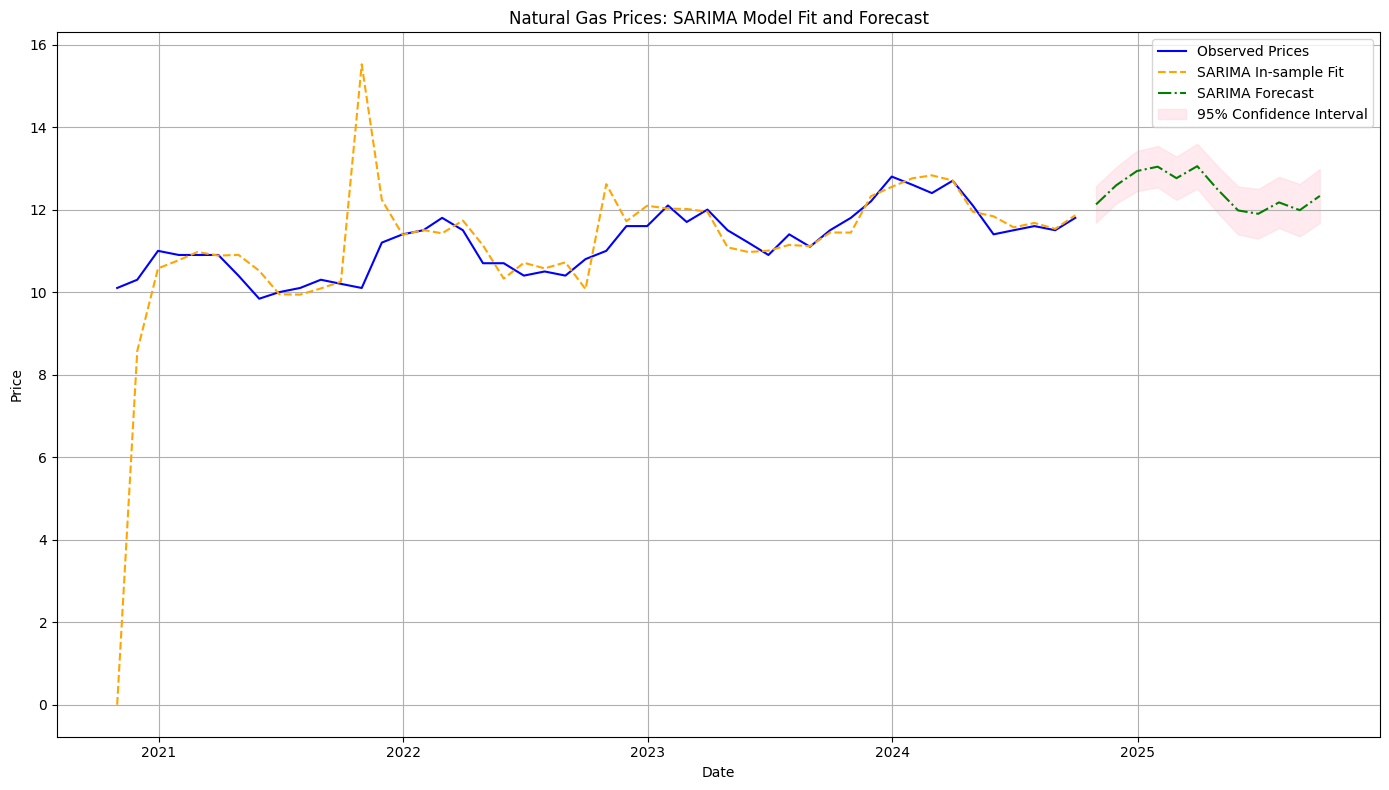


SARIMA Forecast for the next 12 months:
2024-10-31    12.125720
2024-11-30    12.588710
2024-12-31    12.934791
2025-01-31    13.039961
2025-02-28    12.761521
2025-03-31    13.052296
2025-04-30    12.494460
2025-05-31    11.979335
2025-06-30    11.898212
2025-07-31    12.174308
2025-08-31    11.986363
2025-09-30    12.331530
Freq: ME, Name: predicted_mean, dtype: float64


In [25]:
import warnings
import itertools
import statsmodels.api as sm
import matplotlib.pyplot as plt
import pandas as pd

warnings.filterwarnings("ignore") # Suppress harmless warnings

print("### SARIMA Model for Natural Gas Price Prediction ###")

# Ensure the 'df' DataFrame is time-series ready
# It's already loaded with 'Dates' as index and 'Prices' column
if 'df' not in locals():
    print("Error: DataFrame 'df' not found. Please ensure it's loaded in previous cells.")
else:
    # Resample to monthly average if not already monthly, or ensure frequency
    # For simplicity, we'll assume 'df' is already at a consistent frequency (e.g., monthly)
    # based on previous operations. If not, a resampling step like df['Prices'].resample('MS').mean() might be needed.
    y = df['Prices'].copy() # Use a copy to avoid SettingWithCopyWarning

    # Display first few entries of the time series
    print("\nFirst 5 entries of the time series for SARIMA:")
    print(y.head())

    # Define the p, d, q parameters to take any value between 0 and 2
    p = d = q = range(0, 2)
    # Generate all different combinations of p, q, and d triplets
    pdq = list(itertools.product(p, d, q))

    # Generate all different combinations of seasonal p, q, and d triplets
    # For monthly data, a seasonal period 's' of 12 is typical.
    seasonal_pdq = [(x[0], x[1], x[2], 12) for x in list(itertools.product(p, d, q))]

    print("\nExample of SARIMA parameter combinations:")
    print(f"Non-seasonal (p,d,q): {pdq[0]}")
    print(f"Seasonal (P,D,Q,s): {seasonal_pdq[0]}")

    best_aic = float("inf")
    best_pdq = None
    best_seasonal_pdq = None
    best_sarima_model = None

    # This grid search can be time-consuming. For demonstration, we'll limit the search
    # or use a pre-determined reasonable order if the goal is just to show the model.
    # For a full search, uncomment the loops below.

    # --- Simplified approach for demonstration or specific known good parameters ---
    # Using a common order for natural gas prices that often exhibit seasonality
    # (p,d,q) = (1,1,1) and (P,D,Q,s) = (1,1,1,12) is a good starting point.
    try:
        model = sm.tsa.statespace.SARIMAX(y, order=(1, 1, 1), seasonal_order=(1, 1, 1, 12),
                                        enforce_stationarity=False, enforce_invertibility=False)
        results = model.fit(disp=False)
        print("\nSARIMA(1,1,1)(1,1,1,12) model fitted.")
        print(f"AIC: {results.aic:.2f}")
        best_sarima_model = results
    except Exception as e:
        print(f"Could not fit SARIMA(1,1,1)(1,1,1,12) model: {e}")
        print("Attempting a more robust (but slower) grid search for optimal parameters...")
        # Fallback to grid search if the simple model fails or if a more optimal model is desired
        for param in pdq:
            for param_seasonal in seasonal_pdq:
                try:
                    model = sm.tsa.statespace.SARIMAX(y, order=param, seasonal_order=param_seasonal,
                                                    enforce_stationarity=False, enforce_invertibility=False)
                    results = model.fit(disp=False)

                    if results.aic < best_aic:
                        best_aic = results.aic
                        best_pdq = param
                        best_seasonal_pdq = param_seasonal
                        best_sarima_model = results

                except Exception:
                    continue

        if best_sarima_model:
            print(f"\nBest SARIMA model found: SARIMA{best_pdq}{best_seasonal_pdq} - AIC:{best_aic:.2f}")
        else:
            print("No suitable SARIMA model could be fitted with the defined parameter range.")

    if best_sarima_model:
        print(best_sarima_model.summary().tables[1])

        # --- Make predictions ---
        # Predict for the next 12 months (or the number of future periods desired)
        n_forecast_steps = 12 # Predict for 12 months into the future
        forecast = best_sarima_model.get_forecast(steps=n_forecast_steps)
        forecast_ci = forecast.conf_int()

        # Plot the results
        plt.figure(figsize=(14, 8))
        plt.plot(y.index, y, label='Observed Prices', color='blue')

        # Plot in-sample predictions for context
        pred_in_sample = best_sarima_model.predict(start=y.index[0], end=y.index[-1])
        plt.plot(pred_in_sample.index, pred_in_sample, label='SARIMA In-sample Fit', color='orange', linestyle='--')

        # Plot future predictions
        plt.plot(forecast.predicted_mean.index, forecast.predicted_mean, label='SARIMA Forecast', color='green', linestyle='-.')
        plt.fill_between(forecast_ci.index, forecast_ci.iloc[:, 0], forecast_ci.iloc[:, 1], color='pink', alpha=0.3, label='95% Confidence Interval')

        plt.xlabel('Date')
        plt.ylabel('Price')
        plt.title('Natural Gas Prices: SARIMA Model Fit and Forecast')
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

        print("\nSARIMA Forecast for the next 12 months:")
        print(forecast.predicted_mean)
    else:
        print("SARIMA modeling could not be completed.")


In [32]:
from datetime import date, datetime
import math
import pandas as pd # Ensure pandas is imported for DataFrame creation and date operations

# The price_contract function as provided by the user
def price_contract(in_dates, in_prices, out_dates, out_prices, rate, storage_cost_rate, total_vol, injection_withdrawal_cost_rate):
    volume = 0
    buy_cost = 0
    cash_in = 0

    # Ensure dates are in sequence
    all_dates = sorted(list(set(in_dates + out_dates)))

    for i in range(len(all_dates)):
        start_date = all_dates[i]

        if start_date in in_dates:
            # Inject on these dates and sum up cash flows
            if volume <= total_vol - rate:
                volume += rate

                # Cost to purchase gas
                buy_cost += rate * in_prices[in_dates.index(start_date)]
                # Injection cost
                injection_cost = rate * injection_withdrawal_cost_rate
                buy_cost += injection_cost
                print('Injected gas on %s at a price of %s' % (start_date, in_prices[in_dates.index(start_date)]))

            else:
                # We do not want to inject when rate is greater than total volume minus volume
                print('Injection is not possible on date %s as there is insufficient space in the storage facility' % start_date)
        elif start_date in out_dates:
            #Withdraw on these dates and sum cash flows
            if volume >= rate:
                volume -= rate
                cash_in += rate * out_prices[out_dates.index(start_date)]
                # Withdrawal cost
                withdrawal_cost = rate * injection_withdrawal_cost_rate
                cash_in -= withdrawal_cost
                print('Extracted gas on %s at a price of %s' % (start_date, out_prices[out_dates.index(start_date)]))
            else:
                # we cannot withdraw more gas than is actually stored
                print('Extraction is not possible on date %s as there is insufficient volume of gas stored' % start_date)

    # Calculate storage cost for the duration of the contract
    # Ensure min(in_dates) and max(out_dates) are handled correctly if lists are empty.
    # Using a try-except block or checking list emptiness before accessing min/max is safer.
    # For this example, assuming in_dates and out_dates are not empty.
    if in_dates and out_dates:
        duration_in_months = math.ceil((max(out_dates) - min(in_dates)).days / 30.0)
        store_cost = duration_in_months * storage_cost_rate
    else:
        store_cost = 0 # No storage cost if no in/out dates

    return cash_in - store_cost - buy_cost


print("### Contract Valuation with Linear Regression Predicted Prices ###")

# Example usage of price_contract() using predicted prices from simple_lr_model
# Define the injection and withdrawal dates for the contract
in_dates_contract = [date(2022, 1, 1), date(2022, 2, 1), date(2022, 2, 21), date(2022, 4, 1)] #injection dates
out_dates_contract = [date(2022, 2, 27), date(2022, 4, 15), date(2022, 6, 20), date(2022, 12, 1)] # extraction dates

# Convert contract dates to datetime objects for 'Days' calculation
def get_predicted_prices(dates_list, model, df_min_date):
    if not dates_list:
        return []
    # Convert date objects to datetime objects for consistency with df.index
    dt_dates = [datetime(d.year, d.month, d.day) for d in dates_list]

    # Create a temporary DataFrame for these dates to calculate 'Days'
    temp_df = pd.DataFrame(index=pd.to_datetime(dt_dates))
    temp_df['Days'] = (temp_df.index - df_min_date).days

    # Predict prices using the simple_lr_model
    predicted_prices = model.predict(temp_df[['Days']])
    return predicted_prices.tolist()

# Get prices for injection and withdrawal dates using the linear regression model
# Ensure df.index.min() is available from previous cells
contract_in_prices = get_predicted_prices(in_dates_contract, simple_lr_model, df.index.min())
contract_out_prices = get_predicted_prices(out_dates_contract, simple_lr_model, df.index.min())

# Contract parameters
rate = 100000  # rate of gas in cubic feet per day
storage_cost_rate = 10000  # total volume in cubic feet (per month)
injection_withdrawal_cost_rate = 0.0005  # $/cf
max_storage_volume = 500000 # maximum storage capacity of the storage facility

print("\n--- Contract Details ---")
print(f"Injection Dates: {in_dates_contract}")
print(f"Predicted Injection Prices: {[f'{p:.2f}' for p in contract_in_prices]}")
print(f"Withdrawal Dates: {out_dates_contract}")
print(f"Predicted Withdrawal Prices: {[f'{p:.2f}' for p in contract_out_prices]}")

# Calculate the contract value
result = price_contract(
    in_dates_contract, contract_in_prices,
    out_dates_contract, contract_out_prices,
    rate, storage_cost_rate,
    max_storage_volume, injection_withdrawal_cost_rate
)

print(f"\nThe value of the contract is: ${result:.2f}")


### Contract Valuation with Linear Regression Predicted Prices ###

--- Contract Details ---
Injection Dates: [datetime.date(2022, 1, 1), datetime.date(2022, 2, 1), datetime.date(2022, 2, 21), datetime.date(2022, 4, 1)]
Predicted Injection Prices: ['10.84', '10.88', '10.90', '10.95']
Withdrawal Dates: [datetime.date(2022, 2, 27), datetime.date(2022, 4, 15), datetime.date(2022, 6, 20), datetime.date(2022, 12, 1)]
Predicted Withdrawal Prices: ['10.91', '10.97', '11.06', '11.27']
Injected gas on 2022-01-01 at a price of 10.838614652622894
Injected gas on 2022-02-01 at a price of 10.87836823418446
Injected gas on 2022-02-21 at a price of 10.904015706159665
Extracted gas on 2022-02-27 at a price of 10.911709947752227
Injected gas on 2022-04-01 at a price of 10.954028276511314
Extracted gas on 2022-04-15 at a price of 10.971981506893957
Extracted gas on 2022-06-20 at a price of 11.056618164412132
Extracted gas on 2022-12-01 at a price of 11.266927434608808

The value of the contract is: $-57

In [30]:
print("### Preparing SARIMA Forecast for Contract Calculation ###")

# Extract SARIMA forecast dates and predicted prices
sarima_forecast_dates = forecast.predicted_mean.index.tolist()
sarima_forecast_prices = forecast.predicted_mean.tolist()

# Convert datetime objects to date objects for the price_contract function
sarima_forecast_dates_as_date = [d.date() for d in sarima_forecast_dates]

print("SARIMA Forecast Dates (first 5):", sarima_forecast_dates_as_date[:5])
print("SARIMA Forecast Prices (first 5):", [f'{p:.2f}' for p in sarima_forecast_prices[:5]])

### Preparing SARIMA Forecast for Contract Calculation ###
SARIMA Forecast Dates (first 5): [datetime.date(2024, 10, 31), datetime.date(2024, 11, 30), datetime.date(2024, 12, 31), datetime.date(2025, 1, 31), datetime.date(2025, 2, 28)]
SARIMA Forecast Prices (first 5): ['12.13', '12.59', '12.93', '13.04', '12.76']


### Contract Valuation using SARIMA Predicted Prices

Now, let's use these SARIMA predicted prices to evaluate a hypothetical natural gas contract. We'll select some injection and withdrawal dates from the forecasted period and use the corresponding predicted prices.

In [34]:
# Define new contract dates based on the SARIMA forecast period
# Adjust these dates to be within your 'sarima_forecast_dates_as_date' range
in_dates_sarima_contract = [
    sarima_forecast_dates_as_date[0],  # Oct 2024
    sarima_forecast_dates_as_date[2],  # Dec 2024
    sarima_forecast_dates_as_date[5]   # Mar 2025
]
out_dates_sarima_contract = [
    sarima_forecast_dates_as_date[1],  # Nov 2024
    sarima_forecast_dates_as_date[4],  # Feb 2025
    sarima_forecast_dates_as_date[8]   # Jun 2025
]

# Map the selected contract dates to their corresponding SARIMA predicted prices
def get_sarima_prices_for_dates(dates_list, forecast_dates, forecast_prices):
    prices = []
    for contract_date in dates_list:
        try:
            # Find the index of the contract_date in the forecast_dates_as_date list
            idx = forecast_dates.index(contract_date)
            prices.append(forecast_prices[idx])
        except ValueError:
            print(f"Warning: Date {contract_date} not found in SARIMA forecast. Appending NaN.")
            prices.append(np.nan) # Or handle as appropriate
    return prices

sarima_contract_in_prices = get_sarima_prices_for_dates(
    in_dates_sarima_contract, sarima_forecast_dates_as_date, sarima_forecast_prices
)
sarima_contract_out_prices = get_sarima_prices_for_dates(
    out_dates_sarima_contract, sarima_forecast_dates_as_date, sarima_forecast_prices
)

print("\n--- SARIMA Contract Details ---")
print(f"Injection Dates (SARIMA): {in_dates_sarima_contract}")
print(f"Predicted Injection Prices (SARIMA): {[f'{p:.2f}' for p in sarima_contract_in_prices]}")
print(f"Withdrawal Dates (SARIMA): {out_dates_sarima_contract}")
print(f"Predicted Withdrawal Prices (SARIMA): {[f'{p:.2f}' for p in sarima_contract_out_prices]}")

# Contract parameters (using the same as before)
# rate = 100000
# storage_cost_rate = 10000
# injection_withdrawal_cost_rate = 0.0005
# max_storage_volume = 500000

# Calculate the contract value using SARIMA predicted prices
sarima_result = price_contract(
    in_dates_sarima_contract, sarima_contract_in_prices,
    out_dates_sarima_contract, sarima_contract_out_prices,
    rate, storage_cost_rate,
    max_storage_volume, injection_withdrawal_cost_rate
)

print(f"\nThe value of the contract (using SARIMA predictions) is: ${sarima_result:.2f}")


--- SARIMA Contract Details ---
Injection Dates (SARIMA): [datetime.date(2024, 10, 31), datetime.date(2024, 12, 31), datetime.date(2025, 3, 31)]
Predicted Injection Prices (SARIMA): ['12.13', '12.93', '13.05']
Withdrawal Dates (SARIMA): [datetime.date(2024, 11, 30), datetime.date(2025, 2, 28), datetime.date(2025, 6, 30)]
Predicted Withdrawal Prices (SARIMA): ['12.59', '12.76', '11.90']
Injected gas on 2024-10-31 at a price of 12.125719575740872
Extracted gas on 2024-11-30 at a price of 12.588709861640892
Injected gas on 2024-12-31 at a price of 12.934790644721774
Extracted gas on 2025-02-28 at a price of 12.761520754332972
Injected gas on 2025-03-31 at a price of 13.05229612061441
Extracted gas on 2025-06-30 at a price of 11.898211587989824

The value of the contract (using SARIMA predictions) is: $-176736.41


Price predictions is resulting in negative even if the price from the injection data is lower than the price of withdrawal not because the calculation is wrong but instead due to the insufficient gains and fees.

Altering the predicted prices input upto 1 points would result in significant increase in profits even after fees.